In [7]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd


# Define the path to the event log directory
Partial_MLP_fed_avg_TR = [
"../log/results/MLP/partial_data/MLP_fed_avg_TR/_2025-03-10_13-57-06/events.out.tfevents.1741640226.ROG-Strix-GL12.1426974.0",
"../log/results/MLP/partial_data/MLP_fed_avg_TR/_2025-03-10_14-00-42/events.out.tfevents.1741640442.ROG-Strix-GL12.1426974.1",
"../log/results/MLP/partial_data/MLP_fed_avg_TR/_2025-03-10_14-04-16/events.out.tfevents.1741640656.ROG-Strix-GL12.1426974.2"
]


In [8]:
df_dict = {}
algorithms = { "MLP_fed_avg_TR": Partial_MLP_fed_avg_TR}


def extract_metrics(algorithm_name, log_files):
    data = {}
    for run_id, log_file in enumerate(log_files):
        if os.path.exists(log_file):
            try:
                for event in tf.compat.v1.train.summary_iterator(log_file):
                    step = event.step
                    key = (step, run_id, algorithm_name)
                    if key not in data:
                        data[key] = {
                            "Step": step,
                            "Algorithm": algorithm_name,
                            "Run": run_id  # Track the run index
                        }

                    # Extract each metric
                    for value in event.summary.value:
                        if value.tag == "Server_Test_F1_Score":
                            data[key]["server_F1_Score"] = value.simple_value
                        elif value.tag == "Server_Test_Loss":
                            data[key]["server_loss"] = value.simple_value
                        elif value.tag == "Server_Test_Precision":
                            data[key]["server_precision"] = value.simple_value
                        elif value.tag == "Server_Test_Recall":
                            data[key]["server_recall"] = value.simple_value
                        elif value.tag == "Server_Test_Accuracy":
                            data[key]["server_accuracy"] = value.simple_value
                        elif value.tag == "Clients_F1_Score_Test/Client_1":
                            data[key]["client_1_f1_score"] = value.simple_value
                        elif value.tag == "Clients_Accuracy_Test/Client_1":
                            data[key]["client_1_accuracy"] = value.simple_value
                        elif value.tag == "Clients_Precision_Test/Client_1":
                            data[key]["client_1_precision"] = value.simple_value
                        elif value.tag == "Clients_Recall_Test/Client_1":
                            data[key]["client_1_recall"] = value.simple_value

            except Exception as e:
                print (e)

        else:
            raise FileNotFoundError(f"File {log_file} not found")
    # Convert dictionary to a DataFrame
    df = df = pd.DataFrame.from_dict(data, orient="index")

    df = df.fillna(0)  # Fill NaN values with 0

    # Sort by Algorithm, Run, and Step
    df = df.sort_values(by=["Algorithm", "Run", "Step"]).reset_index(drop=True)

    return df if not df.empty else None

# Extract and store DataFrames
df_list = []
for algo_name, files in algorithms.items():
    df = extract_metrics(algo_name, files)
    if df is not None:
        df_list.append(df)

df_all = pd.concat(df_list, ignore_index=True)
df_all.head(10)

,Step,Algorithm,Run,server_accuracy,server_precision,server_recall,server_F1_Score,server_loss,client_1_accuracy,client_1_precision,client_1_recall,client_1_f1_score
0,0,MLP_fed_avg_TR,0,0.137801,0.033665,0.137801,0.052744,0.014573,0.000000,0.000000,0.000000,0.000000
1,1,MLP_fed_avg_TR,0,0.690391,0.805158,0.690391,0.680340,0.007832,0.736383,0.834166,0.736383,0.733160
2,2,MLP_fed_avg_TR,0,0.765322,0.822776,0.765322,0.762992,0.005889,0.796950,0.859207,0.796950,0.797866
3,3,MLP_fed_avg_TR,0,0.811586,0.850898,0.811586,0.814015,0.004821,0.827451,0.879549,0.827451,0.826134
4,4,MLP_fed_avg_TR,0,0.849644,0.876501,0.849644,0.852449,0.004156,0.866231,0.904599,0.866231,0.862882
5,5,MLP_fed_avg_TR,0,0.864126,0.888449,0.864126,0.866982,0.003630,0.883660,0.915663,0.883660,0.879886
6,6,MLP_fed_avg_TR,0,0.880239,0.898764,0.880239,0.882157,0.003213,0.895425,0.921620,0.895425,0.891142
7,7,MLP_fed_avg_TR,0,0.894128,0.905965,0.894128,0.894790,0.002828,0.899782,0.923498,0.899782,0.894954
8,8,MLP_fed_avg_TR,0,0.901690,0.910663,0.901690,0.901708,0.002638,0.901961,0.925725,0.901961,0.897740
9,9,MLP_fed_avg_TR,0,0.909846,0.916755,0.909846,0.908882,0.002521,0.902397,0.923315,0.902397,0.896407


In [ ]:
# # Find the indices of the rows to average
# indices_to_average = df_all[(df_all['Algorithm'] == 'MLP_fed_avg_TR') & (df_all['Run'] == 0) & (df_all['Step'].isin([95, 96, 97, 98, 99]))].index

# # Calculate the mean of the selected rows
# mean_values = df_all.loc[indices_to_average].mean(numeric_only=True)

# # Find the index of the row to be replaced
# index_to_replace = df_all[(df_all['Algorithm'] == 'MLP_fed_avg_TR') & (df_all['Run'] == 0) & (df_all['Step'] == 100)].index

# # Replace the row with the calculated mean values
# df_all.loc[index_to_replace, mean_values.index] = mean_values.values

In [9]:
# Group by Algorithm and Step, then calculate mean and std for each metric
metrics = ['client_1_accuracy', 'client_1_precision', 'client_1_recall', 'client_1_f1_score']
grouped = df_all.groupby(['Algorithm', 'Step'])[metrics].agg(['mean', 'std']).reset_index()

# Flatten the MultiIndex columns
grouped.columns = ['_'.join(col).strip() if col[1] else col[0] for col in grouped.columns.values]
grouped.head()

,Algorithm,Step,client_1_accuracy_mean,client_1_accuracy_std,client_1_precision_mean,client_1_precision_std,client_1_recall_mean,client_1_recall_std,client_1_f1_score_mean,client_1_f1_score_std
0,MLP_fed_avg_TR,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,MLP_fed_avg_TR,1,0.699732,0.034519,0.815066,0.019406,0.699732,0.034519,0.687857,0.050202
2,MLP_fed_avg_TR,2,0.777246,0.019758,0.846981,0.012524,0.777246,0.019758,0.774816,0.023644
3,MLP_fed_avg_TR,3,0.822867,0.014780,0.875630,0.006691,0.822867,0.014780,0.820998,0.014682
4,MLP_fed_avg_TR,4,0.865369,0.016363,0.904279,0.008065,0.865369,0.016363,0.861964,0.015490


In [10]:
df_mean_std = grouped.copy()

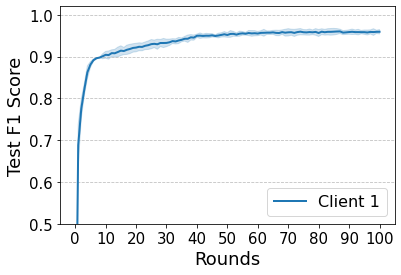

In [58]:


import matplotlib.pyplot as plt
import seaborn as sns

# Define algorithms and their corresponding legend labels
algorithms = ["MLP_fed_avg_TR"]

# Select the metric to visualize
metric = "client_1_f1_score"  # Change this to other metrics if needed
legend_labels = {"MLP_fed_avg_WTR": "Federated-WTR", "MLP_fed_avg_TR": "Federated"}  # Custom legend labels

# Use Seaborn color palette
sns.set_palette("tab10")  # Options: "deep", "muted", "bright", "dark", etc.
colors = sns.color_palette("tab10", n_colors=len(algorithms))  # Get distinct colors

# Assign colors dynamically
color_map = {algorithms[i]: colors[i] for i in range(len(algorithms))}

# Font size configuration
axis_label_fontsize = 18
tick_fontsize = 15
legend_fontsize = 16

# Create the plot
plt.figure(figsize=(6, 4))

for algo in algorithms:
    df_algo = df_mean_std[df_mean_std["Algorithm"] == algo]
    
    steps = df_algo["Step"]
    mean_values = df_algo[f"{metric}_mean"]
    std_values = df_algo[f"{metric}_std"]

    # Plot mean line with custom label
    plt.plot(steps, mean_values, label=f"Client 1", color=color_map[algo], linewidth=2)

    # Add shaded region for standard deviation
    plt.fill_between(steps, mean_values - std_values, mean_values + std_values, color=color_map[algo], alpha=0.2)

# Labels and styling
plt.xlabel("Rounds", fontsize=axis_label_fontsize)
plt.ylabel("Test F1 Score", fontsize=axis_label_fontsize)
plt.xticks(range(0, steps.max() + 1, 10), fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)
plt.ylim(0.5, 1.02)

# Add legend with custom font size
plt.legend(fontsize=legend_fontsize, loc="best", ncol=1)

# Restore only horizontal grid lines
plt.grid(True, axis='y', linestyle='--', alpha=0.8)

# save plot in pdf
plt.savefig(f'{metric}.pdf', bbox_inches='tight')

# Show the plot
plt.show()


In [11]:
# List of metrics to analyze (excluding 'Step' and 'Algorithm')
metrics = [col for col in df_mean_std.columns if col not in ["Algorithm", "Step"] and not "std" in col and not "loss" in col]

# Initialize a dictionary to store results
max_results = []

# Loop through each algorithm and each metric
for algo in df_mean_std["Algorithm"].unique():
    df_algo = df_mean_std[df_mean_std["Algorithm"] == algo]
    
    for metric in metrics:
        max_row = df_algo.loc[df_algo[metric].idxmax()]  # Get the row where max happens
        max_results.append({
            "Algorithm": algo,
            "Metric": metric,
            "Max Value": max_row[metric],
            "Step": max_row["Step"]
        })

# Convert results into a DataFrame
df_max_metrics = pd.DataFrame(max_results)

df_max_metrics

,Algorithm,Metric,Max Value,Step
0,MLP_fed_avg_TR,client_1_accuracy_mean,0.962386,87
1,MLP_fed_avg_TR,client_1_precision_mean,0.965652,87
2,MLP_fed_avg_TR,client_1_recall_mean,0.962386,87
3,MLP_fed_avg_TR,client_1_f1_score_mean,0.960145,87


In [13]:
algorithm = "MLP_fed_avg_TR"
# algorithm = "MLP_fed_avg_WTR"
step = 87
row = df_mean_std[(df_mean_std["Algorithm"] == algorithm) & (df_mean_std["Step"] == step)]
metrics = ['client_1_accuracy_mean', 'client_1_precision_mean', 'client_1_recall_mean', 'client_1_f1_score_mean']

metrics_values = {metric: round(row[metric].values[0], 4) for metric in metrics}
metrics_values

{'client_1_accuracy_mean': 0.9624,
 'client_1_precision_mean': 0.9657,
 'client_1_recall_mean': 0.9624,
 'client_1_f1_score_mean': 0.9601}

In [15]:
# Define the path to the event log directory
Partial_MLP_fed_avg_TR = [
"../log/results/MLP/partial_data/MLP_fed_avg_TR/_2025-03-10_14-25-45/events.out.tfevents.1741641945.ROG-Strix-GL12.1441501.0",
"../log/results/MLP/partial_data/MLP_fed_avg_TR/_2025-03-10_14-29-18/events.out.tfevents.1741642158.ROG-Strix-GL12.1441501.1",
"../log/results/MLP/partial_data/MLP_fed_avg_TR/_2025-03-10_14-32-50/events.out.tfevents.1741642370.ROG-Strix-GL12.1441501.2"
]


df_dict = {}
algorithms = { "MLP_fed_avg_TR": Partial_MLP_fed_avg_TR}


def extract_metrics(algorithm_name, log_files):
    data = {}
    for run_id, log_file in enumerate(log_files):
        if os.path.exists(log_file):
            try:
                for event in tf.compat.v1.train.summary_iterator(log_file):
                    step = event.step
                    key = (step, run_id, algorithm_name)
                    if key not in data:
                        data[key] = {
                            "Step": step,
                            "Algorithm": algorithm_name,
                            "Run": run_id  # Track the run index
                        }

                    # Extract each metric
                    for value in event.summary.value:
                        if value.tag == "Server_Test_F1_Score":
                            data[key]["server_F1_Score"] = value.simple_value
                        elif value.tag == "Server_Test_Loss":
                            data[key]["server_loss"] = value.simple_value
                        elif value.tag == "Server_Test_Precision":
                            data[key]["server_precision"] = value.simple_value
                        elif value.tag == "Server_Test_Recall":
                            data[key]["server_recall"] = value.simple_value
                        elif value.tag == "Server_Test_Accuracy":
                            data[key]["server_accuracy"] = value.simple_value
                        elif value.tag == "Clients_F1_Score_Test/Client_1":
                            data[key]["client_1_f1_score"] = value.simple_value
                        elif value.tag == "Clients_Accuracy_Test/Client_1":
                            data[key]["client_1_accuracy"] = value.simple_value
                        elif value.tag == "Clients_Precision_Test/Client_1":
                            data[key]["client_1_precision"] = value.simple_value
                        elif value.tag == "Clients_Recall_Test/Client_1":
                            data[key]["client_1_recall"] = value.simple_value

                        elif value.tag == "Clients_F1_Score_Test/Client_6":
                            data[key]["client_6_f1_score"] = value.simple_value
                        elif value.tag == "Clients_Accuracy_Test/Client_6":
                            data[key]["client_6_accuracy"] = value.simple_value
                        elif value.tag == "Clients_Precision_Test/Client_6":
                            data[key]["client_6_precision"] = value.simple_value
                        elif value.tag == "Clients_Recall_Test/Client_6":
                            data[key]["client_6_recall"] = value.simple_value
            except Exception as e:
                print (e)

        else:
            raise FileNotFoundError(f"File {log_file} not found")
    # Convert dictionary to a DataFrame
    df = df = pd.DataFrame.from_dict(data, orient="index")

    df = df.fillna(0)  # Fill NaN values with 0

    # Sort by Algorithm, Run, and Step
    df = df.sort_values(by=["Algorithm", "Run", "Step"]).reset_index(drop=True)

    return df if not df.empty else None

# Extract and store DataFrames
df_list = []
for algo_name, files in algorithms.items():
    df = extract_metrics(algo_name, files)
    if df is not None:
        df_list.append(df)

df_all = pd.concat(df_list, ignore_index=True)
df_all.head(10)

# Group by Algorithm and Step, then calculate mean and std for each metric
metrics = ['client_1_accuracy', 'client_1_precision', 'client_1_recall', 'client_1_f1_score', 
           'client_6_accuracy', 'client_6_precision', 'client_6_recall', 'client_6_f1_score', ]
grouped = df_all.groupby(['Algorithm', 'Step'])[metrics].agg(['mean', 'std']).reset_index()

# Flatten the MultiIndex columns
grouped.columns = ['_'.join(col).strip() if col[1] else col[0] for col in grouped.columns.values]
grouped.head()


df_mean_std = grouped.copy()

df_mean_std

,Algorithm,Step,client_1_accuracy_mean,client_1_accuracy_std,client_1_precision_mean,client_1_precision_std,client_1_recall_mean,client_1_recall_std,client_1_f1_score_mean,client_1_f1_score_std,client_6_accuracy_mean,client_6_accuracy_std,client_6_precision_mean,client_6_precision_std,client_6_recall_mean,client_6_recall_std,client_6_f1_score_mean,client_6_f1_score_std
0,MLP_fed_avg_TR,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,MLP_fed_avg_TR,1,0.662667,0.051774,0.820088,0.021774,0.662667,0.051774,0.660680,0.059305,0.618972,0.050650,0.738158,0.049387,0.618972,0.050650,0.590164,0.051592
2,MLP_fed_avg_TR,2,0.777307,0.018739,0.853333,0.015163,0.777307,0.018739,0.782883,0.018127,0.706355,0.002576,0.772988,0.059237,0.706355,0.002576,0.688311,0.003292
3,MLP_fed_avg_TR,3,0.822549,0.019134,0.877926,0.015121,0.822549,0.019134,0.826511,0.018413,0.748509,0.006119,0.787225,0.059115,0.748509,0.006119,0.727856,0.005873
4,MLP_fed_avg_TR,4,0.866726,0.007615,0.907225,0.005227,0.866726,0.007615,0.868179,0.006636,0.775587,0.013322,0.814185,0.052179,0.775587,0.013322,0.753576,0.012440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,MLP_fed_avg_TR,96,0.958614,0.002403,0.962792,0.002689,0.958614,0.002403,0.956167,0.002877,0.941534,0.001214,0.956387,0.001220,0.941534,0.001214,0.939016,0.001483
97,MLP_fed_avg_TR,97,0.958247,0.003736,0.962436,0.003677,0.958247,0.003736,0.955690,0.004172,0.939559,0.001253,0.955315,0.001795,0.939559,0.001253,0.936755,0.001281
98,MLP_fed_avg_TR,98,0.956950,0.001435,0.961307,0.001735,0.956950,0.001435,0.954148,0.001675,0.939875,0.002190,0.956032,0.002616,0.939875,0.002190,0.937015,0.002443
99,MLP_fed_avg_TR,99,0.956812,0.002989,0.961530,0.003335,0.956812,0.002989,0.953990,0.003808,0.935309,0.005282,0.954340,0.002571,0.935309,0.005282,0.931256,0.006708


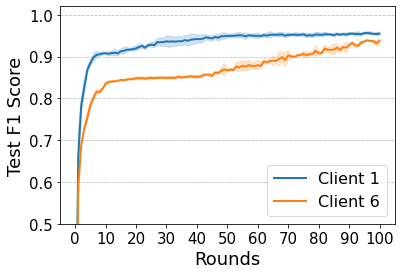

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define algorithms and their corresponding legend labels
algorithms = ["MLP_fed_avg_TR"]

# Select the metrics to visualize
metrics_f1 = ["client_1_f1_score", "client_6_f1_score"]  # Add more metrics if needed
legend_labels = {"MLP_fed_avg_WTR": "Federated-WTR", "MLP_fed_avg_TR": "Federated"}  # Custom legend labels

# Use Seaborn color palette
sns.set_palette("tab10")  # Options: "deep", "muted", "bright", "dark", etc.
colors = sns.color_palette("tab10", n_colors=len(algorithms) * len(metrics_f1))  # Get distinct colors

# Assign colors dynamically
color_map = {f"{algo}_{metric}": colors[i] for i, (algo, metric) in enumerate([(algo, metric) for algo in algorithms for metric in metrics_f1])}

# Font size configuration
axis_label_fontsize = 18
tick_fontsize = 15
legend_fontsize = 16

# Create the plot
plt.figure(figsize=(6, 4))

for algo in algorithms:
    for metric in metrics_f1:
        df_algo = df_mean_std[df_mean_std["Algorithm"] == algo]
        
        steps = df_algo["Step"]
        mean_values = df_algo[f"{metric}_mean"]
        std_values = df_algo[f"{metric}_std"]

        # Plot mean line with custom label
        plt.plot(steps, mean_values, label=f"Client {metric.split('_')[1]}", color=color_map[f"{algo}_{metric}"], linewidth=2)

        # Add shaded region for standard deviation
        plt.fill_between(steps, mean_values - std_values, mean_values + std_values, color=color_map[f"{algo}_{metric}"], alpha=0.2)

# Labels and styling
plt.xlabel("Rounds", fontsize=axis_label_fontsize)
plt.ylabel("Test F1 Score", fontsize=axis_label_fontsize)
plt.xticks(range(0, steps.max() + 1, 10), fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)
plt.ylim(0.5, 1.02)

# Add legend with custom font size
plt.legend(fontsize=legend_fontsize, loc="best", ncol=1)

# Restore only horizontal grid lines
plt.grid(True, axis='y', linestyle='--', alpha=0.8)

# save plot in pdf
plt.savefig(f'{metrics_f1}.pdf', bbox_inches='tight')
# Show the plot
plt.show()


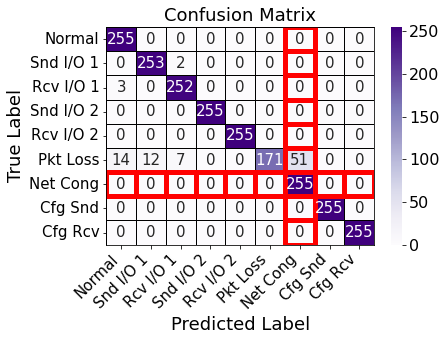

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the confusion matrix
client_1_conf_matrix = np.array([
    [255,   0,   0,   0,   0,   0,   0,   0,   0],
    [  0, 253,   2,   0,   0,   0,   0,   0,   0],
    [  3,   0, 252,   0,   0,   0,   0,   0,   0],
    [  0,   0,   0, 255,   0,   0,   0,   0,   0],
    [  0,   0,   0,   0, 255,   0,   0,   0,   0],
    [ 14,  12,   7,   0,   0, 171,  51,   0,   0],
    [ 0,   0,   0,   0,   0, 0,   255,   0,   0],  # Highlight this row
    [  0,   0,   0,   0,   0,   0,   0, 255,   0],
    [  0,   0,   0,   0,   0,   0,   0,   0, 255]
])

# class_labels = [
#     "Normal", 
#     "Snd I/O Anom (Storage)",   # Sender-side I/O anomaly on shared storage
#     "Rcv I/O Anom (Host)",      # Receiver-side I/O anomaly on receiver host
#     "Snd I/O Anom 2 (Storage)", # Second sender-side I/O anomaly on shared storage
#     "Rcv I/O Anom 2 (Host)",    # Second receiver-side I/O anomaly on receiver host
#     "Pkt Loss", 
#     "Net Cong", 
#     "Cfg Anom Snd", 
#     "Cfg Anom Rcv"
# ]

class_labels = [
    "Normal", 
    "Snd I/O 1",  
    "Rcv I/O 1",  
    "Snd I/O 2",  
    "Rcv I/O 2",  
    "Pkt Loss", 
    "Net Cong", 
    "Cfg Snd", 
    "Cfg Rcv"
]
# Font size configuration
axis_label_fontsize = 18
tick_fontsize = 15
legend_fontsize = 16

# Create a DataFrame for visualization
df_cm = pd.DataFrame(client_1_conf_matrix, index=class_labels, columns=class_labels)


# Plot the confusion matrix
plt.figure(figsize=(6, 4))
ax = sns.heatmap(df_cm, annot=True, fmt="d", cmap="Purples", linewidths=.5, linecolor="black", vmin=0, cbar=True, annot_kws={"size": tick_fontsize})



# # Manually set the color bar limits to start from 0 while keeping vmin=20 for the heatmap
# colorbar = ax.collections[0].colorbar
# colorbar.set_ticks(np.arange(0, conf_matrix.max() + 1, 50))
# colorbar.set_label("Value Scale")

# Highlight the row "Network Congestion Between Two Hosts"
highlight_row_idx = class_labels.index("Net Cong")
for _, spine in ax.spines.items():
    spine.set_visible(True)
    
for i in range(len(class_labels)):
    ax.add_patch(plt.Rectangle((i, highlight_row_idx), 1, 1, fill=True, edgecolor="red", lw=5, facecolor="none"))
    ax.add_patch(plt.Rectangle((highlight_row_idx, i), 1, 1, fill=True, edgecolor="red", lw=5, facecolor="none"))

# Apply font size settings
plt.xlabel("Predicted Label", fontsize=axis_label_fontsize)
plt.ylabel("True Label", fontsize=axis_label_fontsize)
plt.title("Confusion Matrix", fontsize=axis_label_fontsize)
plt.xticks(rotation=45, ha="right", fontsize=tick_fontsize)
plt.yticks(rotation=0, fontsize=tick_fontsize)

# Adjust color bar font size
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=legend_fontsize)

# save plot in pdf
plt.savefig(f'client_1_conf_matrix.pdf', bbox_inches='tight')

plt.show()


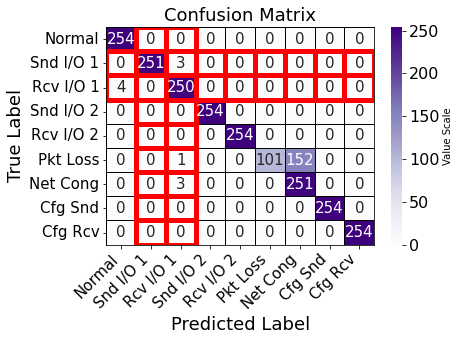

In [49]:
# Scenario 2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the confusion matrix
client_6_conf_matrix = np.array([
    [254,   0,   0,   0,   0,   0,   0,   0,   0],
    [  0, 251,   3,   0,   0,   0,   0,   0,   0],
    [  4,   0, 250,   0,   0,   0,   0,   0,   0],
    [  0,   0,   0, 254,   0,   0,   0,   0,   0],
    [  0,   0,   0,   0, 254,   0,   0,   0,   0],
    [  0,   0,   1,   0,   0, 101, 152,   0,   0],
    [  0,   0,   3,   0,   0,   0, 251,   0,   0],
    [  0,   0,   0,   0,   0,   0,   0, 254,   0],
    [  0,   0,   0,   0,   0,   0,   0,   0, 254]
])
# class_labels = [
#     "Normal", 
#     "Snd I/O Anom (Storage)",   # Sender-side I/O anomaly on shared storage
#     "Rcv I/O Anom (Host)",      # Receiver-side I/O anomaly on receiver host
#     "Snd I/O Anom 2 (Storage)", # Second sender-side I/O anomaly on shared storage
#     "Rcv I/O Anom 2 (Host)",    # Second receiver-side I/O anomaly on receiver host
#     "Pkt Loss", 
#     "Net Cong", 
#     "Cfg Anom Snd", 
#     "Cfg Anom Rcv"
# ]

class_labels = [
    "Normal", 
    "Snd I/O 1",  
    "Rcv I/O 1",  
    "Snd I/O 2",  
    "Rcv I/O 2",  
    "Pkt Loss", 
    "Net Cong", 
    "Cfg Snd", 
    "Cfg Rcv"
]
# Font size configuration
axis_label_fontsize = 18
tick_fontsize = 15
legend_fontsize = 16

# Create a DataFrame for visualization
df_cm = pd.DataFrame(client_6_conf_matrix, index=class_labels, columns=class_labels)


# Plot the confusion matrix
plt.figure(figsize=(6, 4))
ax = sns.heatmap(df_cm, annot=True, fmt="d", cmap="Purples", linewidths=.5, linecolor="black", vmin=0, cbar=True, annot_kws={"size": tick_fontsize})


red_highlight = ["Net Cong"]
blue_highlight = ["Snd I/O 1", "Rcv I/O 1"]
# Get indices for highlighted rows
red_indices = [class_labels.index(row) for row in red_highlight]
blue_indices = [class_labels.index(row) for row in blue_highlight]

# Ensure all spines are visible
for _, spine in ax.spines.items():
    spine.set_visible(True)

# Apply different highlight colors
# for idx in red_indices:
#     for i in range(len(class_labels)):
#         ax.add_patch(plt.Rectangle((i, idx), 1, 1, fill=True, edgecolor="red", lw=3, facecolor="none"))
#         ax.add_patch(plt.Rectangle((idx, i), 1, 1, fill=True, edgecolor="red", lw=3, facecolor="none"))

for idx in blue_indices:
    for i in range(len(class_labels)):
        ax.add_patch(plt.Rectangle((i, idx), 1, 1, fill=True, edgecolor="red", lw=5, facecolor="none"))
        ax.add_patch(plt.Rectangle((idx, i), 1, 1, fill=True, edgecolor="red", lw=5, facecolor="none"))
# # Manually set the color bar limits to start from 0 while keeping vmin=20 for the heatmap
colorbar = ax.collections[0].colorbar
colorbar.set_ticks(np.arange(0, client_6_conf_matrix.max() + 1, 50))
colorbar.set_label("Value Scale")


# Apply font size settings
plt.xlabel("Predicted Label", fontsize=axis_label_fontsize)
plt.ylabel("True Label", fontsize=axis_label_fontsize)
plt.title("Confusion Matrix", fontsize=axis_label_fontsize)
plt.xticks(rotation=45, ha="right", fontsize=tick_fontsize)
plt.yticks(rotation=0, fontsize=tick_fontsize)

# Adjust color bar font size
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=legend_fontsize)

# save plot in pdf
plt.savefig(f'client_6_conf_matrix.pdf', bbox_inches='tight')

plt.show()

In [16]:
# List of metrics to analyze (excluding 'Step' and 'Algorithm')
metrics = [col for col in df_mean_std.columns if col not in ["Algorithm", "Step"] and not "std" in col and not "loss" in col]

# Initialize a dictionary to store results
max_results = []

# Loop through each algorithm and each metric
for algo in df_mean_std["Algorithm"].unique():
    df_algo = df_mean_std[df_mean_std["Algorithm"] == algo]
    
    for metric in metrics:
        max_row = df_algo.loc[df_algo[metric].idxmax()]  # Get the row where max happens
        max_results.append({
            "Algorithm": algo,
            "Metric": metric,
            "Max Value": max_row[metric],
            "Step": max_row["Step"]
        })

# Convert results into a DataFrame
df_max_metrics = pd.DataFrame(max_results)

df_max_metrics

,Algorithm,Metric,Max Value,Step
0,MLP_fed_avg_TR,client_1_accuracy_mean,0.958614,96
1,MLP_fed_avg_TR,client_1_precision_mean,0.962905,95
2,MLP_fed_avg_TR,client_1_recall_mean,0.958614,96
3,MLP_fed_avg_TR,client_1_f1_score_mean,0.956167,96
4,MLP_fed_avg_TR,client_6_accuracy_mean,0.941534,96
5,MLP_fed_avg_TR,client_6_precision_mean,0.956725,100
6,MLP_fed_avg_TR,client_6_recall_mean,0.941534,96
7,MLP_fed_avg_TR,client_6_f1_score_mean,0.939016,96


In [17]:
algorithm = "MLP_fed_avg_TR"
# algorithm = "MLP_fed_avg_WTR"
step = 96
row = df_mean_std[(df_mean_std["Algorithm"] == algorithm) & (df_mean_std["Step"] == step)]
metrics = ['client_1_accuracy_mean', 'client_1_precision_mean', 'client_1_recall_mean', 'client_1_f1_score_mean',
           'client_6_accuracy_mean', 'client_6_precision_mean', 'client_6_recall_mean', 'client_6_f1_score_mean',]

metrics_values = {metric: round(row[metric].values[0], 4) for metric in metrics}
metrics_values

{'client_1_accuracy_mean': 0.9586,
 'client_1_precision_mean': 0.9628,
 'client_1_recall_mean': 0.9586,
 'client_1_f1_score_mean': 0.9562,
 'client_6_accuracy_mean': 0.9415,
 'client_6_precision_mean': 0.9564,
 'client_6_recall_mean': 0.9415,
 'client_6_f1_score_mean': 0.939}